# Part C � ML Models for Prepayment

This notebook renders Part C's figures from parquet files written by
`part_c_ml_models.py`. All plotting lives here; the compute script does
no plotting.

**Models compared:**

- **LogReg** � L2-regularized logistic regression (linear baseline)
- **RF** � Random Forest classifier (200 trees, depth 12)
- **LGBM** � LightGBM with early stopping (gradient boosting)
- **Cox** � Cox proportional hazards (Part B-style) -> predictions
  derived as $1 - \hat S(T \mid X)$ at each horizon

**Horizons:** 12 / 24 / 36 / 60 months.

**Target framing:** the value of `target_mode.txt` written by Part C
controls what "the target" means at each horizon (see concern 6 in the
response doc):

- `cause_specific` (default) � prepayment-by-T = 1, observed-past-T = 0,
  non-prepayment termination before T = NaN (censored). Matches Cox
  naturally.
- `binary` � prepayment-by-T = 1, everything-else = 0.

The notebook reads the mode and labels charts accordingly.


In [14]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "results_cd" else NB_DIR
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import roc_curve

from utilities import (
    RESULTS_CD,
    HORIZONS,
    MODEL_ORDER,
    MODEL_COLORS,
    FICO_BUCKETS,
    LABEL_MAP,
    apply_plot_style,
    read_target_mode,
)

apply_plot_style()

TARGET_MODE = read_target_mode()
print(f"Target mode (from results_cd/target_mode.txt): {TARGET_MODE!r}")


Target mode (from results_cd/target_mode.txt): 'cause_specific'


In [15]:
predictions = pd.read_parquet(RESULTS_CD / "C_predictions.parquet")
metrics = pd.read_parquet(RESULTS_CD / "C_metrics.parquet")
calibration = pd.read_parquet(RESULTS_CD / "C_calibration.parquet")
feature_importance = pd.read_parquet(RESULTS_CD / "C_feature_importance.parquet")

# Identify which models actually produced predictions
models_present = []
for m in MODEL_ORDER[:4]:  # LogReg, RF, LGBM, Cox
    cols = [f"pred_{m}_T{T}" for T in HORIZONS]
    if all(c in predictions.columns for c in cols):
        # Cox columns may be all-NaN if Cox failed to converge � keep
        # the model in the list but the plotting code will skip when
        # there's no data
        models_present.append(m)
print("Models present:", models_present)

print()
print(f"Predictions:        {len(predictions):,} rows, "
      f"{predictions.shape[1]} columns")
print(f"Metrics:            {len(metrics):,} rows")
print(f"Calibration:        {len(calibration):,} rows")
print(f"Feature importance: {len(feature_importance):,} rows")


Models present: ['LogReg', 'RF', 'LGBM', 'Cox']

Predictions:        597,205 rows, 29 columns
Metrics:            192 rows
Calibration:        160 rows
Feature importance: 816 rows


## ROC curves by horizon

For each prediction horizon, the receiver operating characteristic
(ROC) curve plots the true-positive rate against the false-positive
rate as the decision threshold sweeps across all values. Closer to the
top-left corner means stronger discrimination. The numbers in the
legend are AUCs (area under the curve).


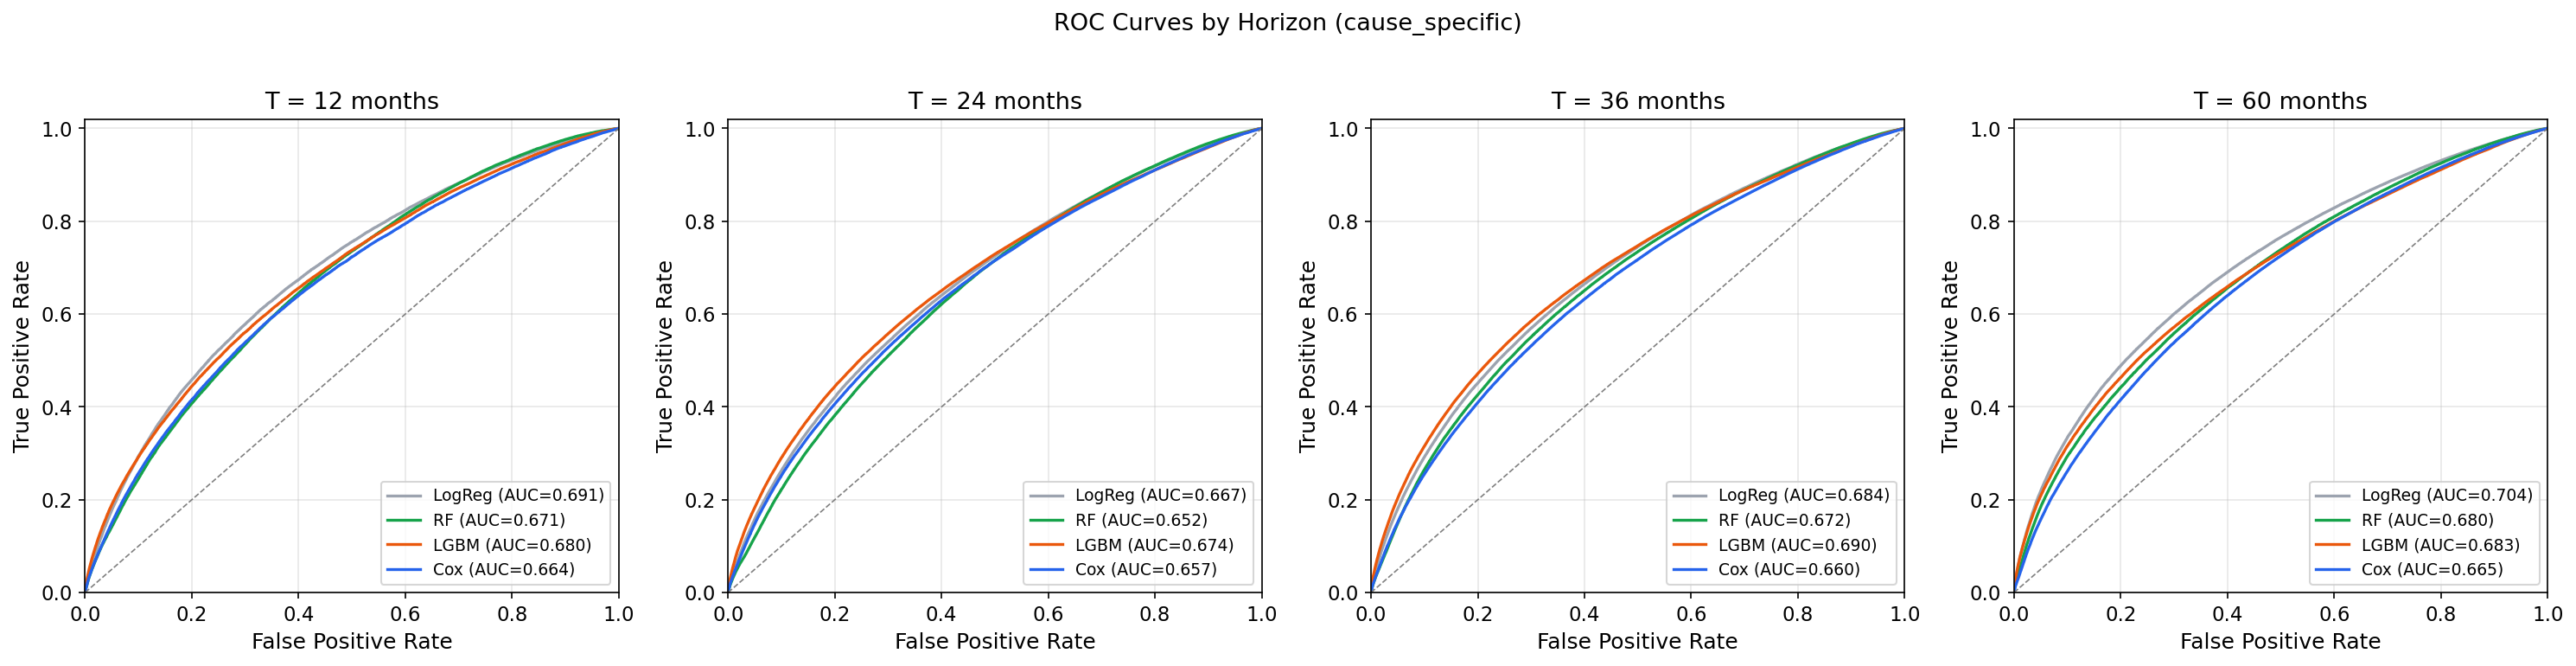

In [16]:
def plot_roc_curves(preds, models, mode_label):
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 5),
                              squeeze=False)
    axes = axes.ravel()
    for ax, T in zip(axes, HORIZONS):
        target = preds[f"Target_T{T}"]
        valid_target = target.notna()
        for m in models:
            pcol = f"pred_{m}_T{T}"
            if pcol not in preds.columns:
                continue
            valid = valid_target & preds[pcol].notna()
            if valid.sum() < 100:
                continue
            y = target[valid].astype(int).values
            p = preds.loc[valid, pcol].values
            if len(np.unique(y)) < 2:
                continue
            fpr, tpr, _ = roc_curve(y, p)
            from sklearn.metrics import roc_auc_score
            auc = roc_auc_score(y, p)
            ax.plot(fpr, tpr, color=MODEL_COLORS[m], linewidth=1.6,
                    label=f"{m} (AUC={auc:.3f})")
        ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=0.8)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"T = {T} months")
        ax.legend(loc="lower right", fontsize=9)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
    fig.suptitle(f"ROC Curves by Horizon ({mode_label})",
                 fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

plot_roc_curves(predictions, models_present, TARGET_MODE)


## AUC by horizon

Overall AUC (across all test loans) for each model and horizon. Higher
is better; 0.5 is no better than random.


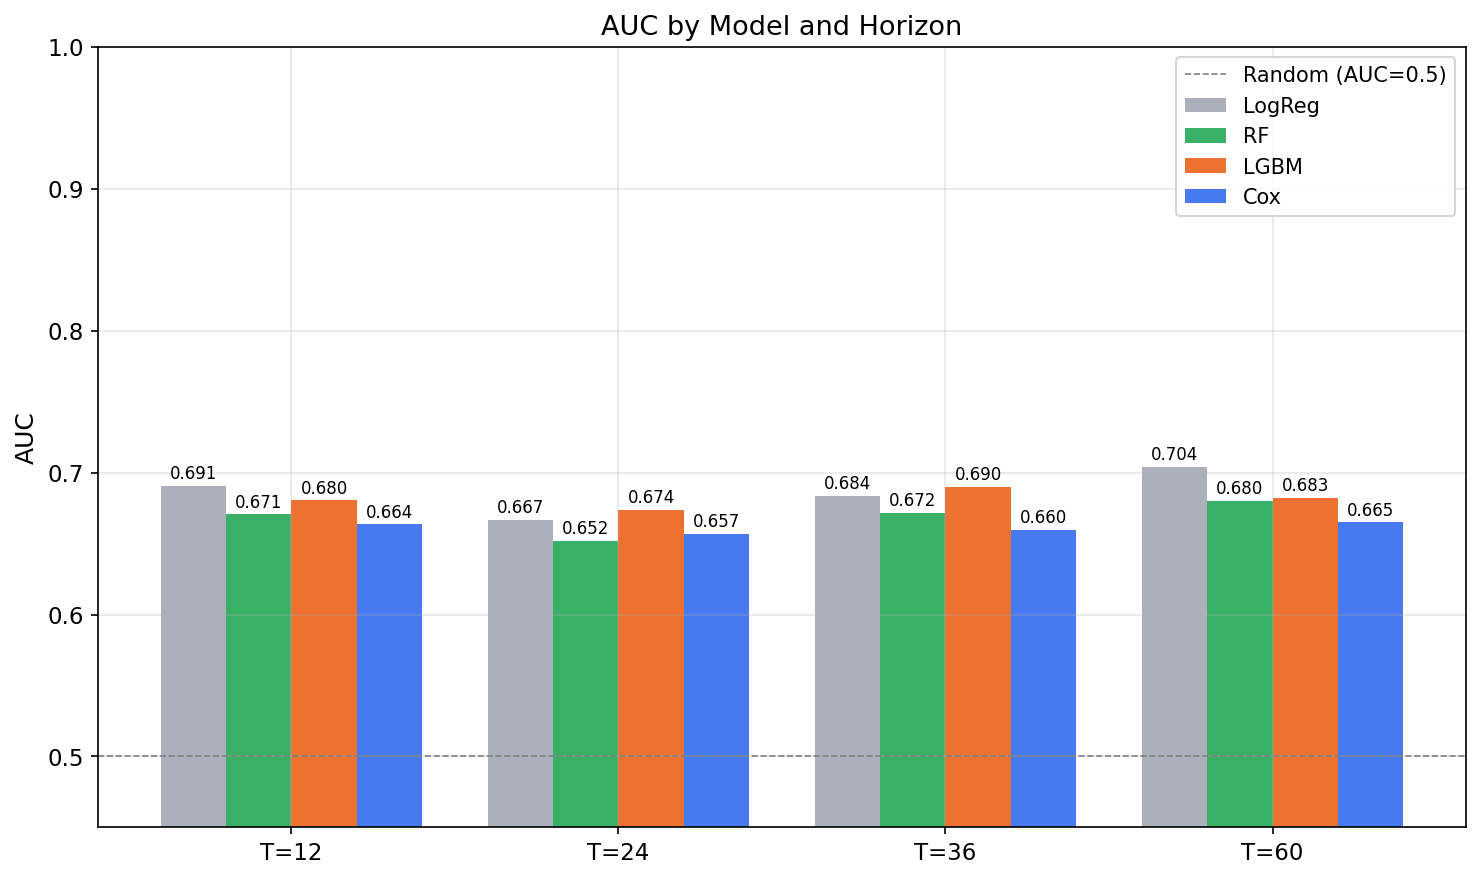

AUC by model � horizon:
horizon      12      24      36      60
model                                  
Cox      0.6635  0.6571  0.6596  0.6650
LGBM     0.6805  0.6738  0.6899  0.6825
LogReg   0.6908  0.6670  0.6837  0.7043
RF       0.6706  0.6519  0.6718  0.6803


In [17]:
def plot_auc_by_horizon(metrics, models):
    overall = metrics[metrics["stratum_type"] == "all"].copy()
    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.8 / max(len(models), 1)
    x = np.arange(len(HORIZONS))
    for i, m in enumerate(models):
        sub = overall[overall["model"] == m].set_index("horizon")
        if sub.empty:
            continue
        aucs = [sub.loc[T, "auc"] if T in sub.index else np.nan for T in HORIZONS]
        offset = (i - (len(models) - 1) / 2) * width
        bars = ax.bar(x + offset, aucs, width, color=MODEL_COLORS[m],
                       label=m, alpha=0.85)
        for j, v in enumerate(aucs):
            if pd.notna(v):
                ax.text(x[j] + offset, v + 0.005, f"{v:.3f}",
                        ha="center", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"T={T}" for T in HORIZONS])
    ax.set_ylabel("AUC")
    ax.set_title("AUC by Model and Horizon")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8,
                label="Random (AUC=0.5)")
    ax.legend()
    ax.set_ylim(0.45, 1.0)
    fig.tight_layout()
    plt.show()

plot_auc_by_horizon(metrics, models_present)

# Print the table too
print("AUC by model � horizon:")
print(metrics[metrics["stratum_type"] == "all"]
      .pivot_table(index="model", columns="horizon",
                   values="auc", aggfunc="first")
      .round(4).to_string())


## Brier score, log-loss, and accuracy

Three additional summary metrics:

- **Brier score** � mean squared error between predicted probability
  and observed outcome. Lower is better; ranges in $[0, 1]$ but
  practically lives in $[0, 0.25]$ for binary problems.
- **Log loss** � cross-entropy. Heavily penalizes confident wrong
  predictions. Lower is better.
- **Accuracy at threshold 0.5** � coarse, dependent on class balance,
  but useful as a sanity check.


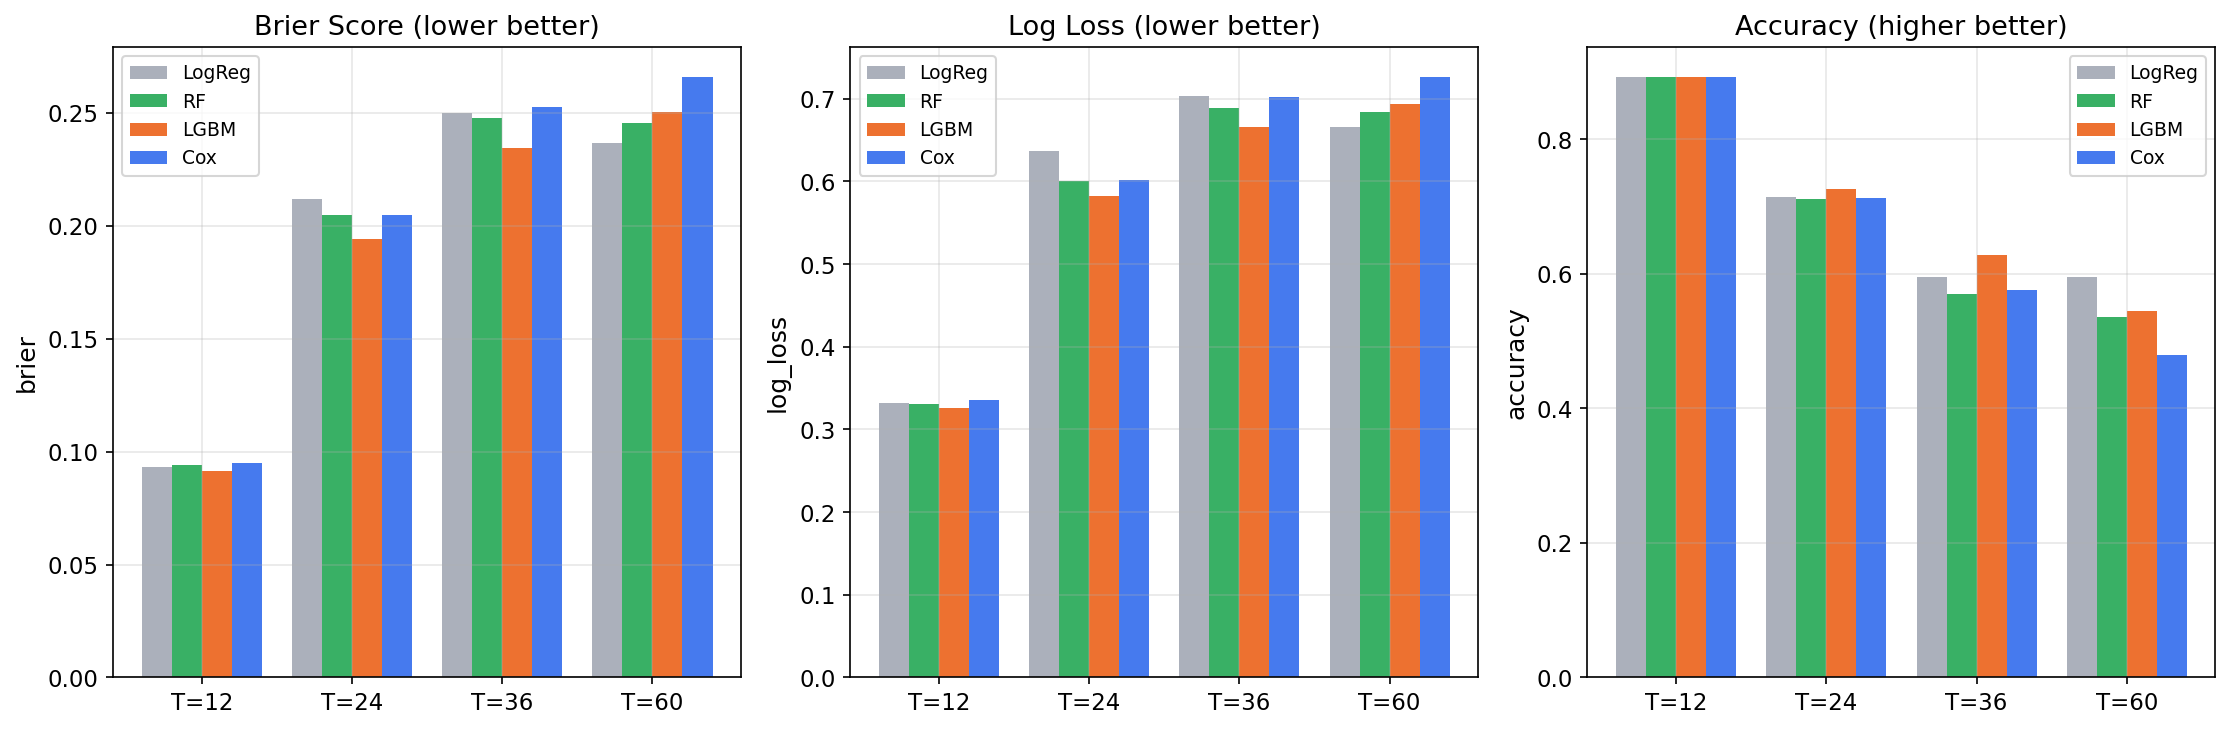

In [18]:
def plot_metrics_summary(metrics, models):
    overall = metrics[metrics["stratum_type"] == "all"].copy()
    metric_specs = [
        ("brier",    "Brier Score (lower better)"),
        ("log_loss", "Log Loss (lower better)"),
        ("accuracy", "Accuracy (higher better)"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (metric, label) in zip(axes, metric_specs):
        width = 0.8 / max(len(models), 1)
        x = np.arange(len(HORIZONS))
        for i, m in enumerate(models):
            sub = overall[overall["model"] == m].set_index("horizon")
            if sub.empty:
                continue
            vals = [sub.loc[T, metric] if T in sub.index else np.nan
                    for T in HORIZONS]
            offset = (i - (len(models) - 1) / 2) * width
            ax.bar(x + offset, vals, width, color=MODEL_COLORS[m],
                   label=m, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels([f"T={T}" for T in HORIZONS])
        ax.set_ylabel(metric)
        ax.set_title(label)
        ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

plot_metrics_summary(metrics, models_present)


## Calibration

Decile reliability plot: do predicted probabilities match observed
rates? On the diagonal = perfectly calibrated. Above = under-predicting
(model says 20% but actual rate is 30%). Below = over-predicting.


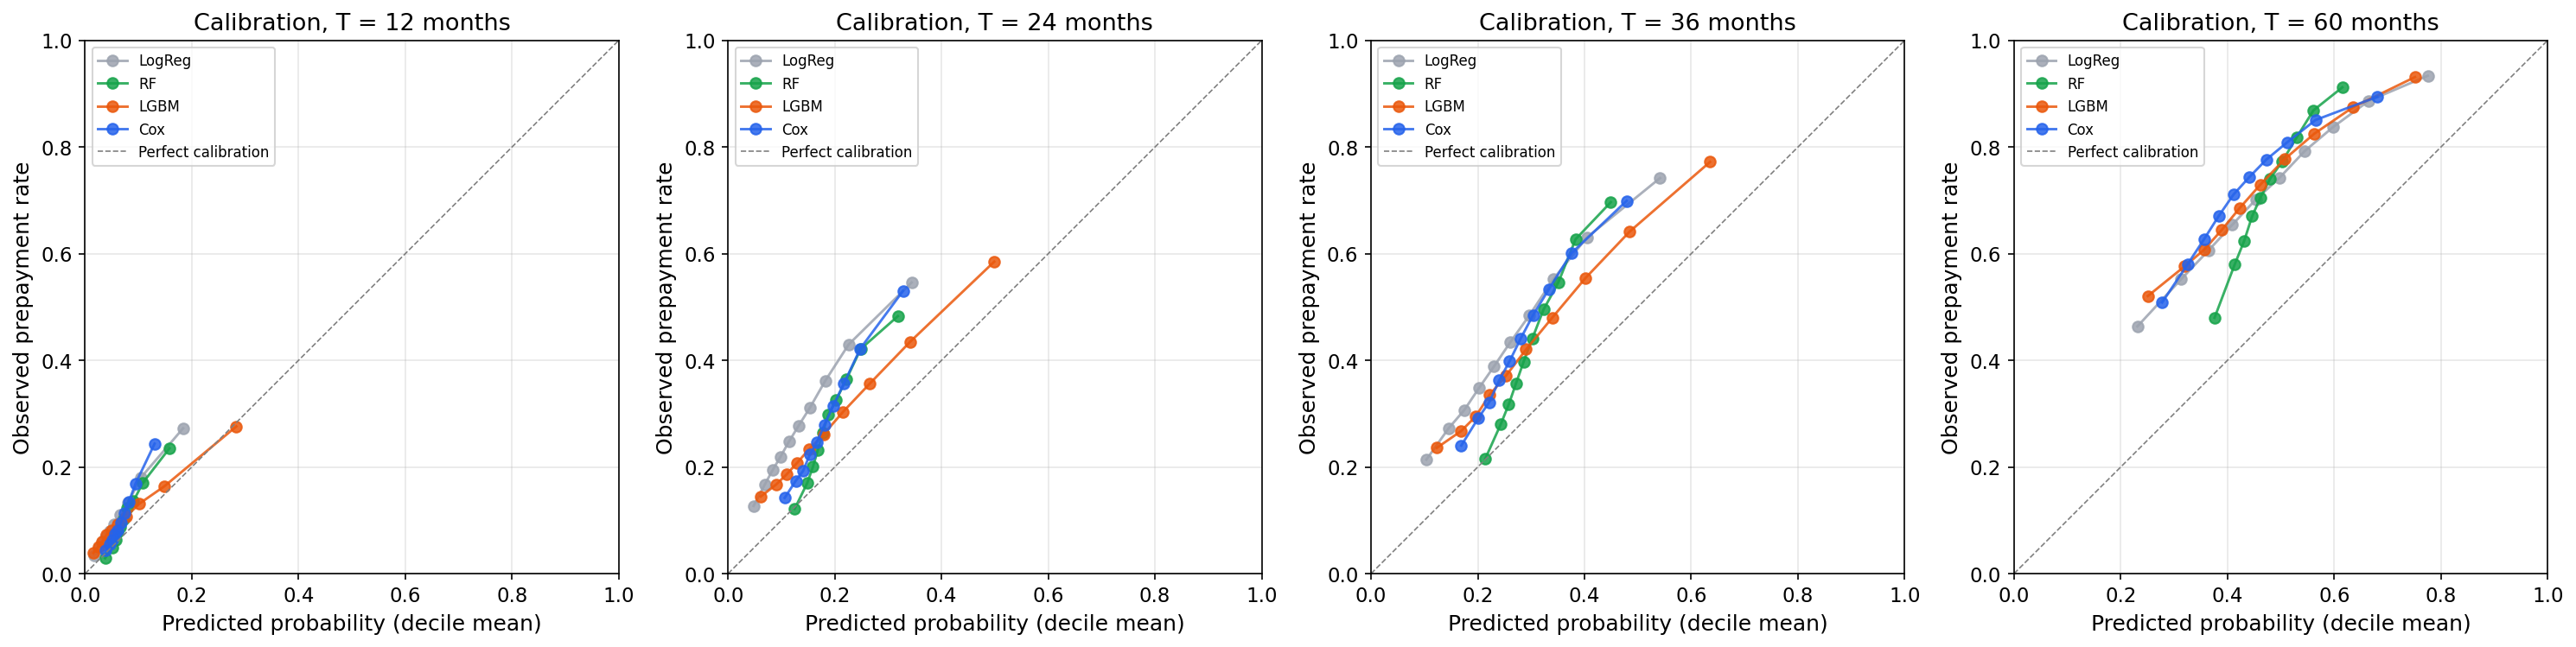

In [19]:
def plot_calibration(calib, models):
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 5),
                              squeeze=False)
    axes = axes.ravel()
    for ax, T in zip(axes, HORIZONS):
        for m in models:
            sub = calib[(calib["model"] == m) & (calib["horizon"] == T)]
            if sub.empty:
                continue
            ax.plot(sub["pred_mean"], sub["observed_rate"], "o-",
                    color=MODEL_COLORS[m], linewidth=1.4, markersize=6,
                    label=m, alpha=0.85)
        ax.plot([0, 1], [0, 1], "--", color="gray",
                linewidth=0.8, label="Perfect calibration")
        ax.set_xlabel("Predicted probability (decile mean)")
        ax.set_ylabel("Observed prepayment rate")
        ax.set_title(f"Calibration, T = {T} months")
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    plt.show()

plot_calibration(calibration, models_present)


## AUC by vintage

Test-set AUC stratified by origination vintage. If the model's AUC
drops sharply for some vintages (typically the earliest or latest in
the test set), that's a sign of regime change in borrower behaviour or
of distributional drift in the covariates.


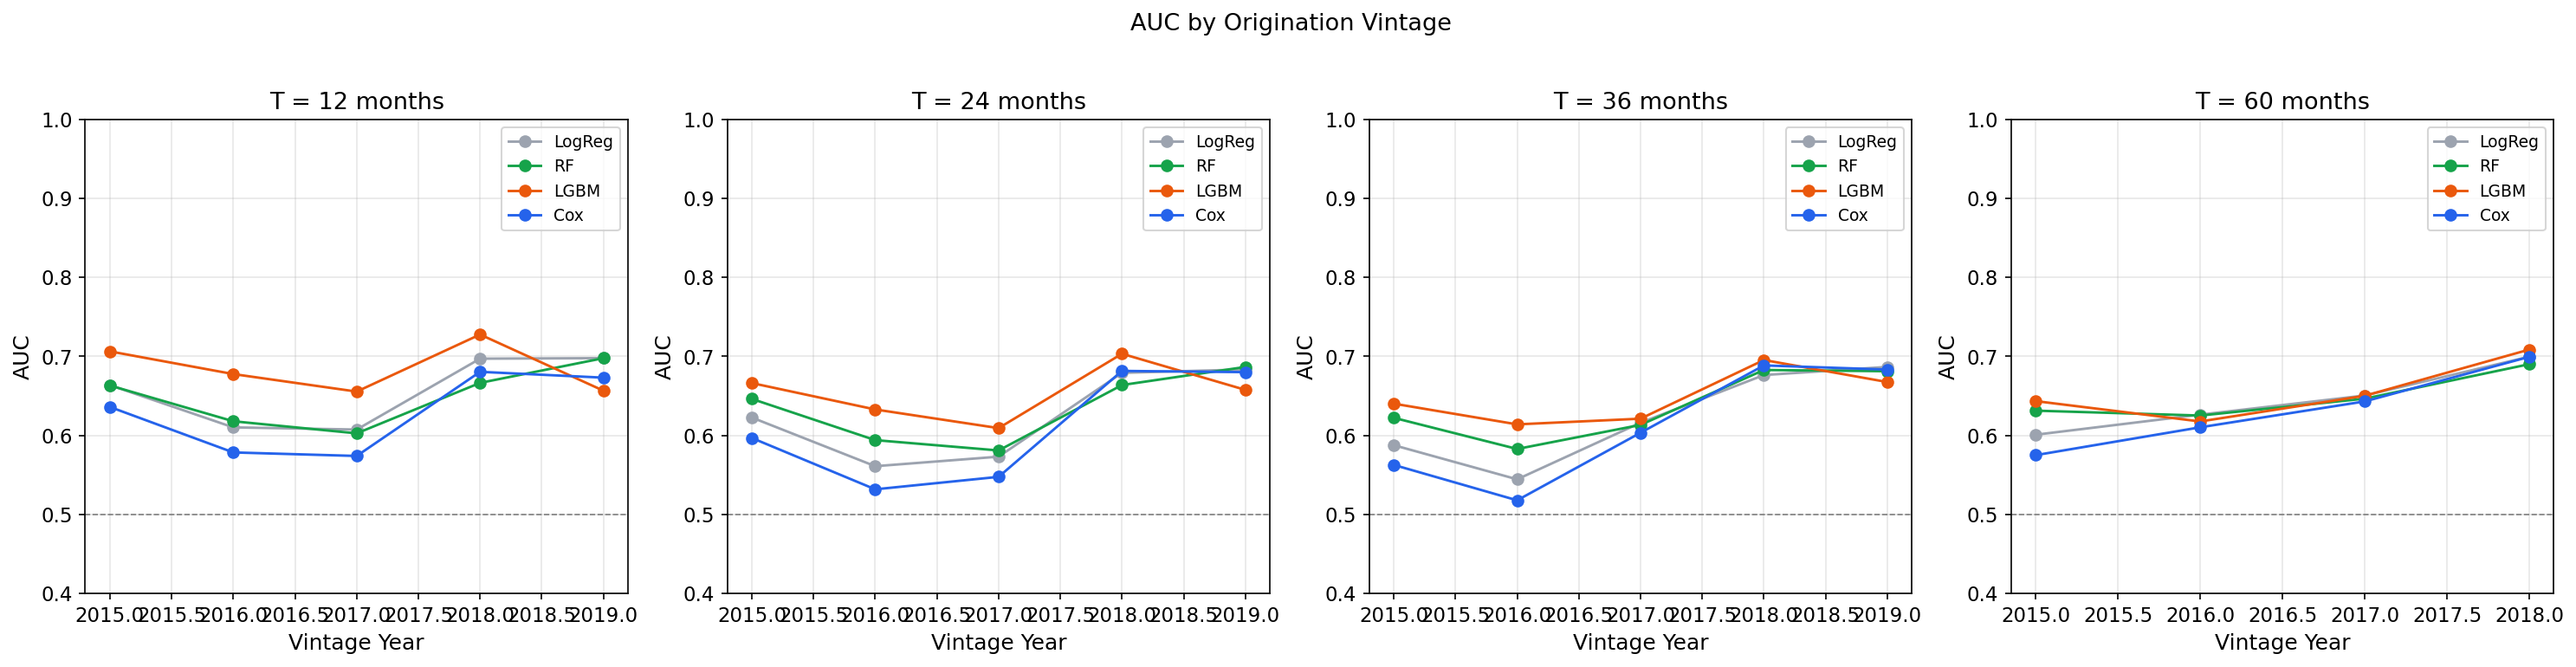

In [20]:
def plot_auc_by_vintage(metrics, models):
    sub = metrics[metrics["stratum_type"] == "vintage"].copy()
    sub["vintage"] = sub["stratum_value"].astype(int)
    vintages = sorted(sub["vintage"].unique())

    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 5),
                              squeeze=False)
    axes = axes.ravel()
    for ax, T in zip(axes, HORIZONS):
        sub_T = sub[sub["horizon"] == T]
        for m in models:
            mdf = sub_T[sub_T["model"] == m].set_index("vintage")
            if mdf.empty:
                continue
            aucs = [mdf.loc[v, "auc"] if v in mdf.index else np.nan
                    for v in vintages]
            ax.plot(vintages, aucs, "o-", color=MODEL_COLORS[m],
                    linewidth=1.4, markersize=6, label=m)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
        ax.set_xlabel("Vintage Year")
        ax.set_ylabel("AUC")
        ax.set_title(f"T = {T} months")
        ax.legend(fontsize=9)
        ax.set_ylim(0.4, 1.0)
    fig.suptitle("AUC by Origination Vintage", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

plot_auc_by_vintage(metrics, models_present)


## AUC by FICO bucket

Test-set AUC stratified by borrower credit quality. The 740-779 / 780+
buckets typically have the most prepayment activity (since high-FICO
borrowers can refinance more easily), so models often have more signal
to work with there.


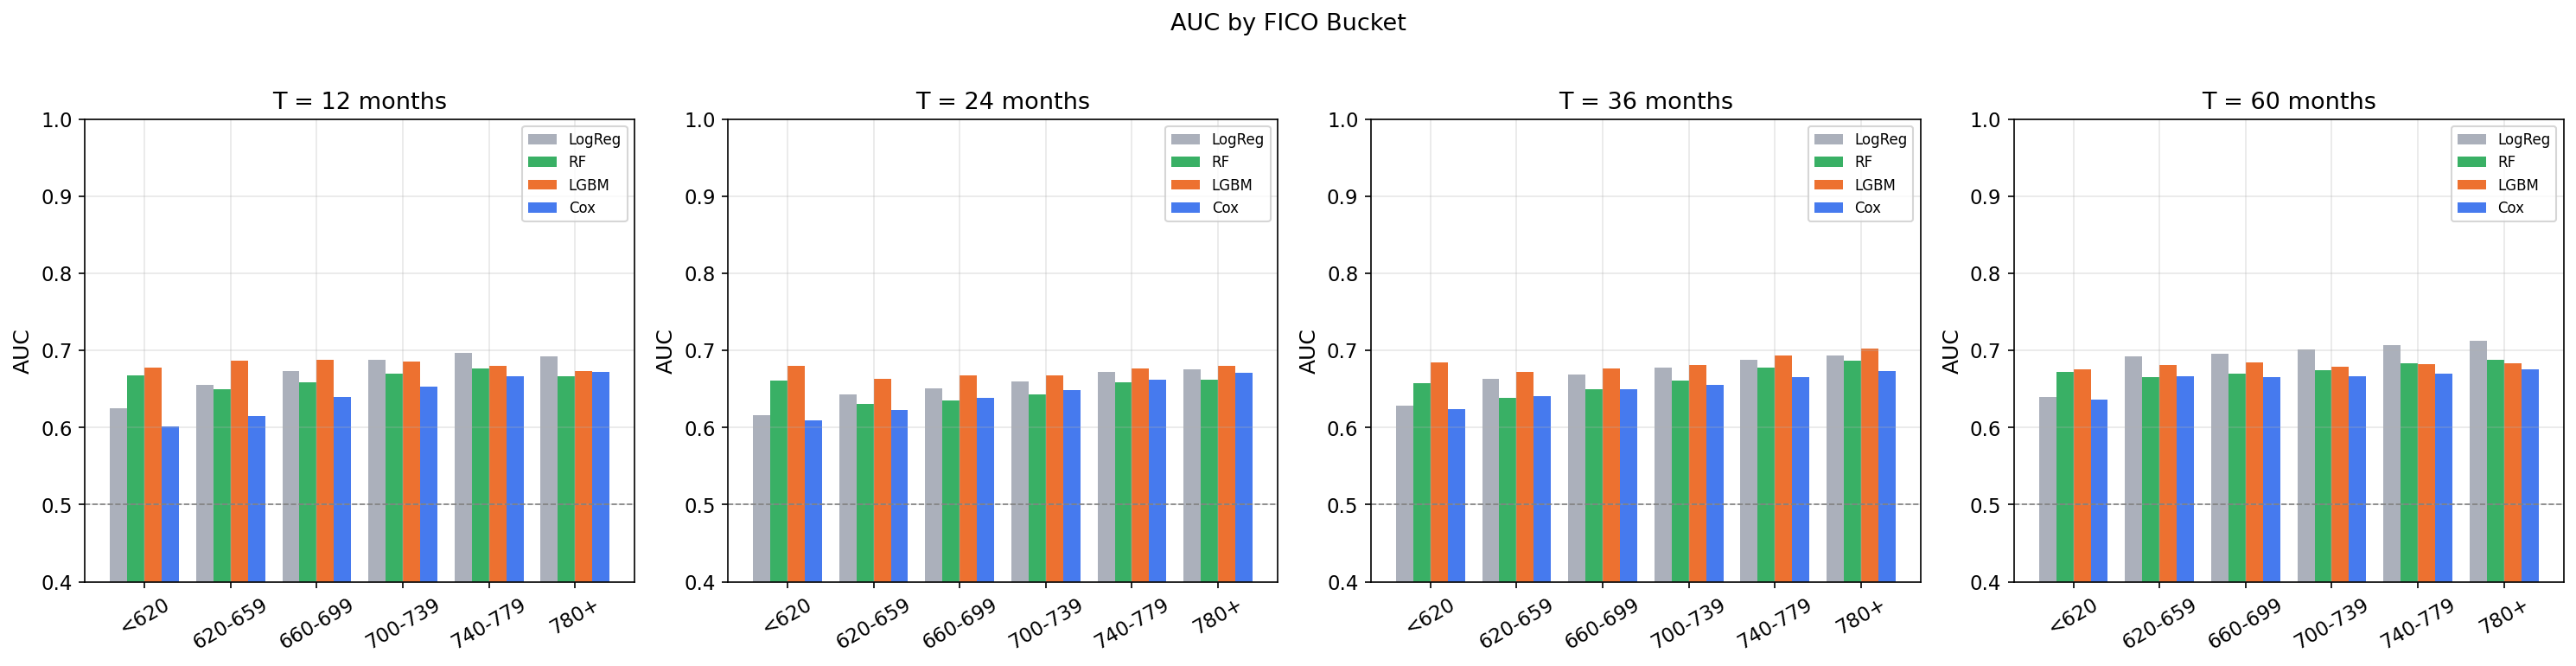

In [21]:
def plot_auc_by_fico(metrics, models):
    sub = metrics[metrics["stratum_type"] == "FICO"].copy()
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 5),
                              squeeze=False)
    axes = axes.ravel()
    for ax, T in zip(axes, HORIZONS):
        sub_T = sub[sub["horizon"] == T]
        x = np.arange(len(FICO_BUCKETS))
        width = 0.8 / max(len(models), 1)
        for i, m in enumerate(models):
            mdf = sub_T[sub_T["model"] == m].set_index("stratum_value")
            aucs = [mdf.loc[fb, "auc"] if fb in mdf.index else np.nan
                    for fb in FICO_BUCKETS]
            offset = (i - (len(models) - 1) / 2) * width
            ax.bar(x + offset, aucs, width, color=MODEL_COLORS[m],
                   label=m, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(FICO_BUCKETS, rotation=30)
        ax.set_ylabel("AUC")
        ax.set_title(f"T = {T} months")
        ax.legend(fontsize=8)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
        ax.set_ylim(0.4, 1.0)
    fig.suptitle("AUC by FICO Bucket", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

plot_auc_by_fico(metrics, models_present)


## Top-decile lift

For each model, what fraction of loans in the top-10% scored bucket
actually prepay by horizon $T$? Compared against the overall
prepayment rate (the dashed line). A "lift" of 2.0 means top-decile
loans prepay at twice the baseline rate � a useful summary of the
model's ability to rank loans for an investor doing buy-and-hold
selection.


In [22]:
def compute_top_decile_lift(preds, models):
    rows = []
    for T in HORIZONS:
        target = preds[f"Target_T{T}"]
        valid_target = target.notna()
        baseline = float(target[valid_target].mean()) if valid_target.any() else np.nan
        for m in models:
            pcol = f"pred_{m}_T{T}"
            if pcol not in preds.columns:
                continue
            valid = valid_target & preds[pcol].notna()
            if valid.sum() < 100:
                continue
            y = target[valid].astype(int).values
            p = preds.loc[valid, pcol].values
            cutoff = np.quantile(p, 0.9)
            top = p >= cutoff
            if top.sum() == 0:
                continue
            top_rate = float(y[top].mean())
            rows.append({
                "model": m, "horizon": T,
                "baseline": baseline,
                "top_decile_rate": top_rate,
                "lift": top_rate / baseline if baseline > 0 else np.nan,
            })
    return pd.DataFrame(rows)

lift_df = compute_top_decile_lift(predictions, models_present)
print("Top-decile lift table:")
print(lift_df.round(4).to_string(index=False))


Top-decile lift table:
 model  horizon  baseline  top_decile_rate   lift
LogReg       12    0.1075           0.2726 2.5356
    RF       12    0.1075           0.2351 2.1869
  LGBM       12    0.1075           0.2761 2.5687
   Cox       12    0.1075           0.2438 2.2679
LogReg       24    0.2879           0.5459 1.8960
    RF       24    0.2879           0.4828 1.6770
  LGBM       24    0.2879           0.5850 2.0319
   Cox       24    0.2879           0.5299 1.8405
LogReg       36    0.4373           0.7417 1.6962
    RF       36    0.4373           0.6966 1.5929
  LGBM       36    0.4373           0.7719 1.7653
   Cox       36    0.4373           0.6990 1.5985
LogReg       60    0.7170           0.9336 1.3020
    RF       60    0.7170           0.9118 1.2717
  LGBM       60    0.7170           0.9312 1.2987
   Cox       60    0.7170           0.8941 1.2470


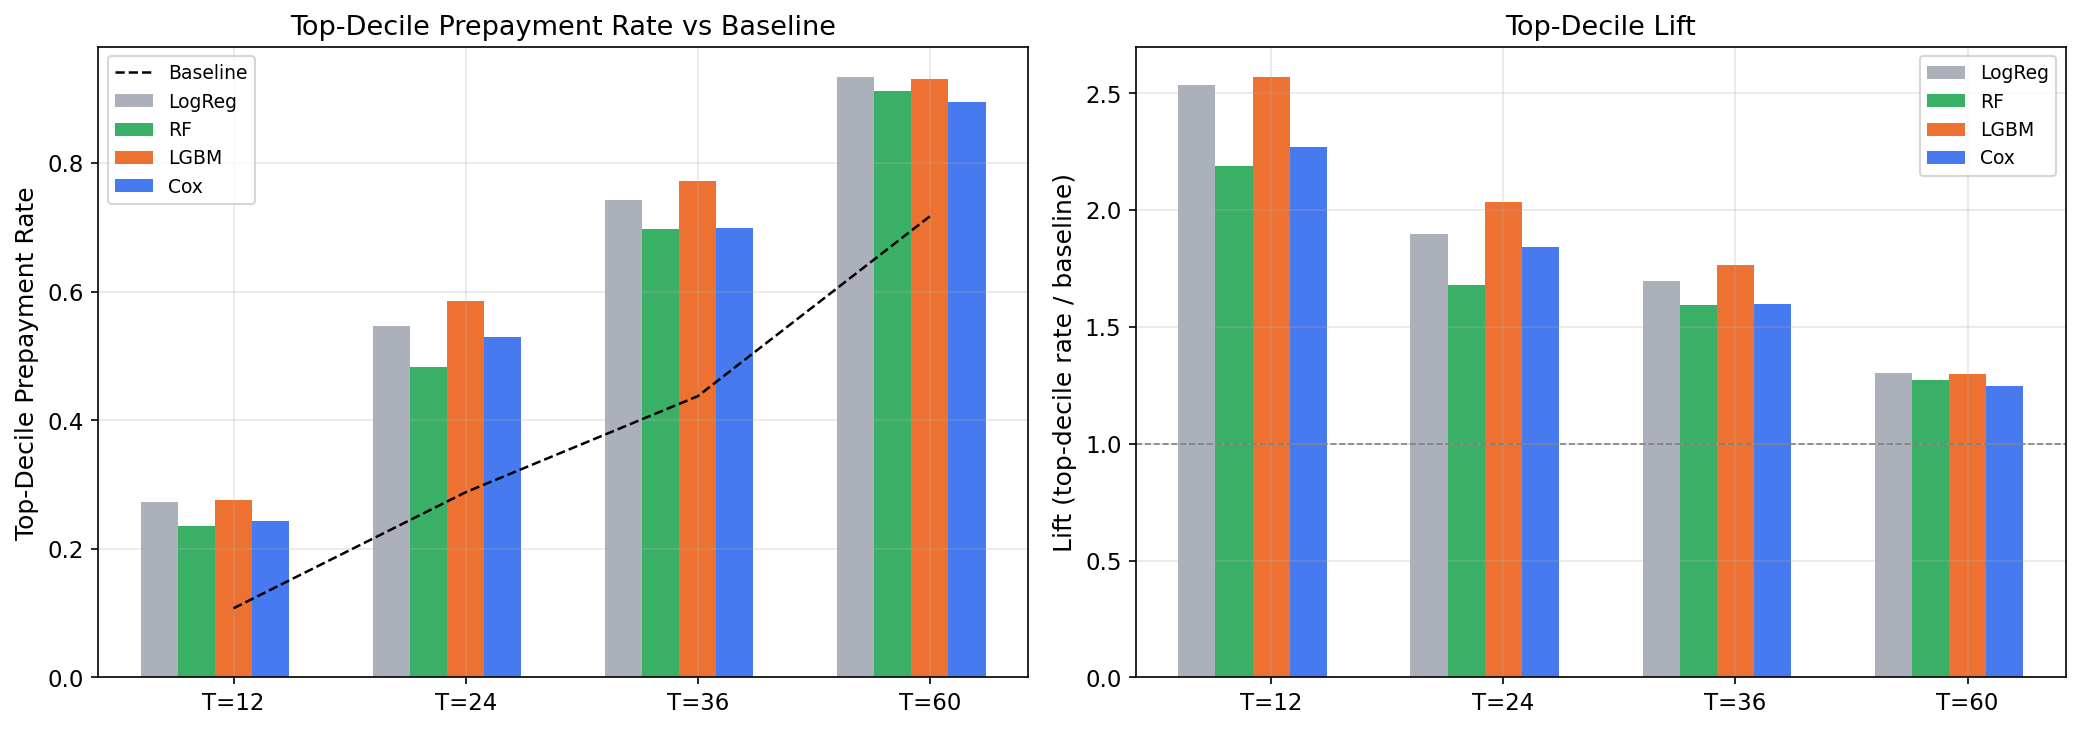

In [23]:
def plot_lift(lift_df, models):
    if lift_df.empty:
        print("No lift data to plot.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(HORIZONS))
    width = 0.8 / max(len(models) + 1, 1)

    # Left: top-decile prepayment rate vs baseline
    ax = axes[0]
    for i, m in enumerate(models):
        sub = lift_df[lift_df["model"] == m].set_index("horizon")
        rates = [sub.loc[T, "top_decile_rate"] if T in sub.index else np.nan
                 for T in HORIZONS]
        offset = (i - len(models) / 2) * width
        ax.bar(x + offset, rates, width, color=MODEL_COLORS[m],
               label=m, alpha=0.85)
    # Baseline line per horizon (use any model's baseline - they should agree)
    base_per_T = lift_df.groupby("horizon")["baseline"].first().reindex(HORIZONS)
    ax.plot(x, base_per_T.values, "k--", linewidth=1.2, label="Baseline")
    ax.set_xticks(x)
    ax.set_xticklabels([f"T={T}" for T in HORIZONS])
    ax.set_ylabel("Top-Decile Prepayment Rate")
    ax.set_title("Top-Decile Prepayment Rate vs Baseline")
    ax.legend(fontsize=9)

    # Right: lift ratio
    ax = axes[1]
    for i, m in enumerate(models):
        sub = lift_df[lift_df["model"] == m].set_index("horizon")
        lifts = [sub.loc[T, "lift"] if T in sub.index else np.nan
                 for T in HORIZONS]
        offset = (i - len(models) / 2) * width
        ax.bar(x + offset, lifts, width, color=MODEL_COLORS[m],
               label=m, alpha=0.85)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"T={T}" for T in HORIZONS])
    ax.set_ylabel("Lift (top-decile rate / baseline)")
    ax.set_title("Top-Decile Lift")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

plot_lift(lift_df, models_present)


## Score distributions

Histograms of predicted probabilities for each model. A peaky
distribution near 0 means the model is confident most loans don't
prepay; a long right tail means the model picks out a small subset of
likely-prepay loans confidently. Compare across models for one horizon
to see how risk is being distributed.


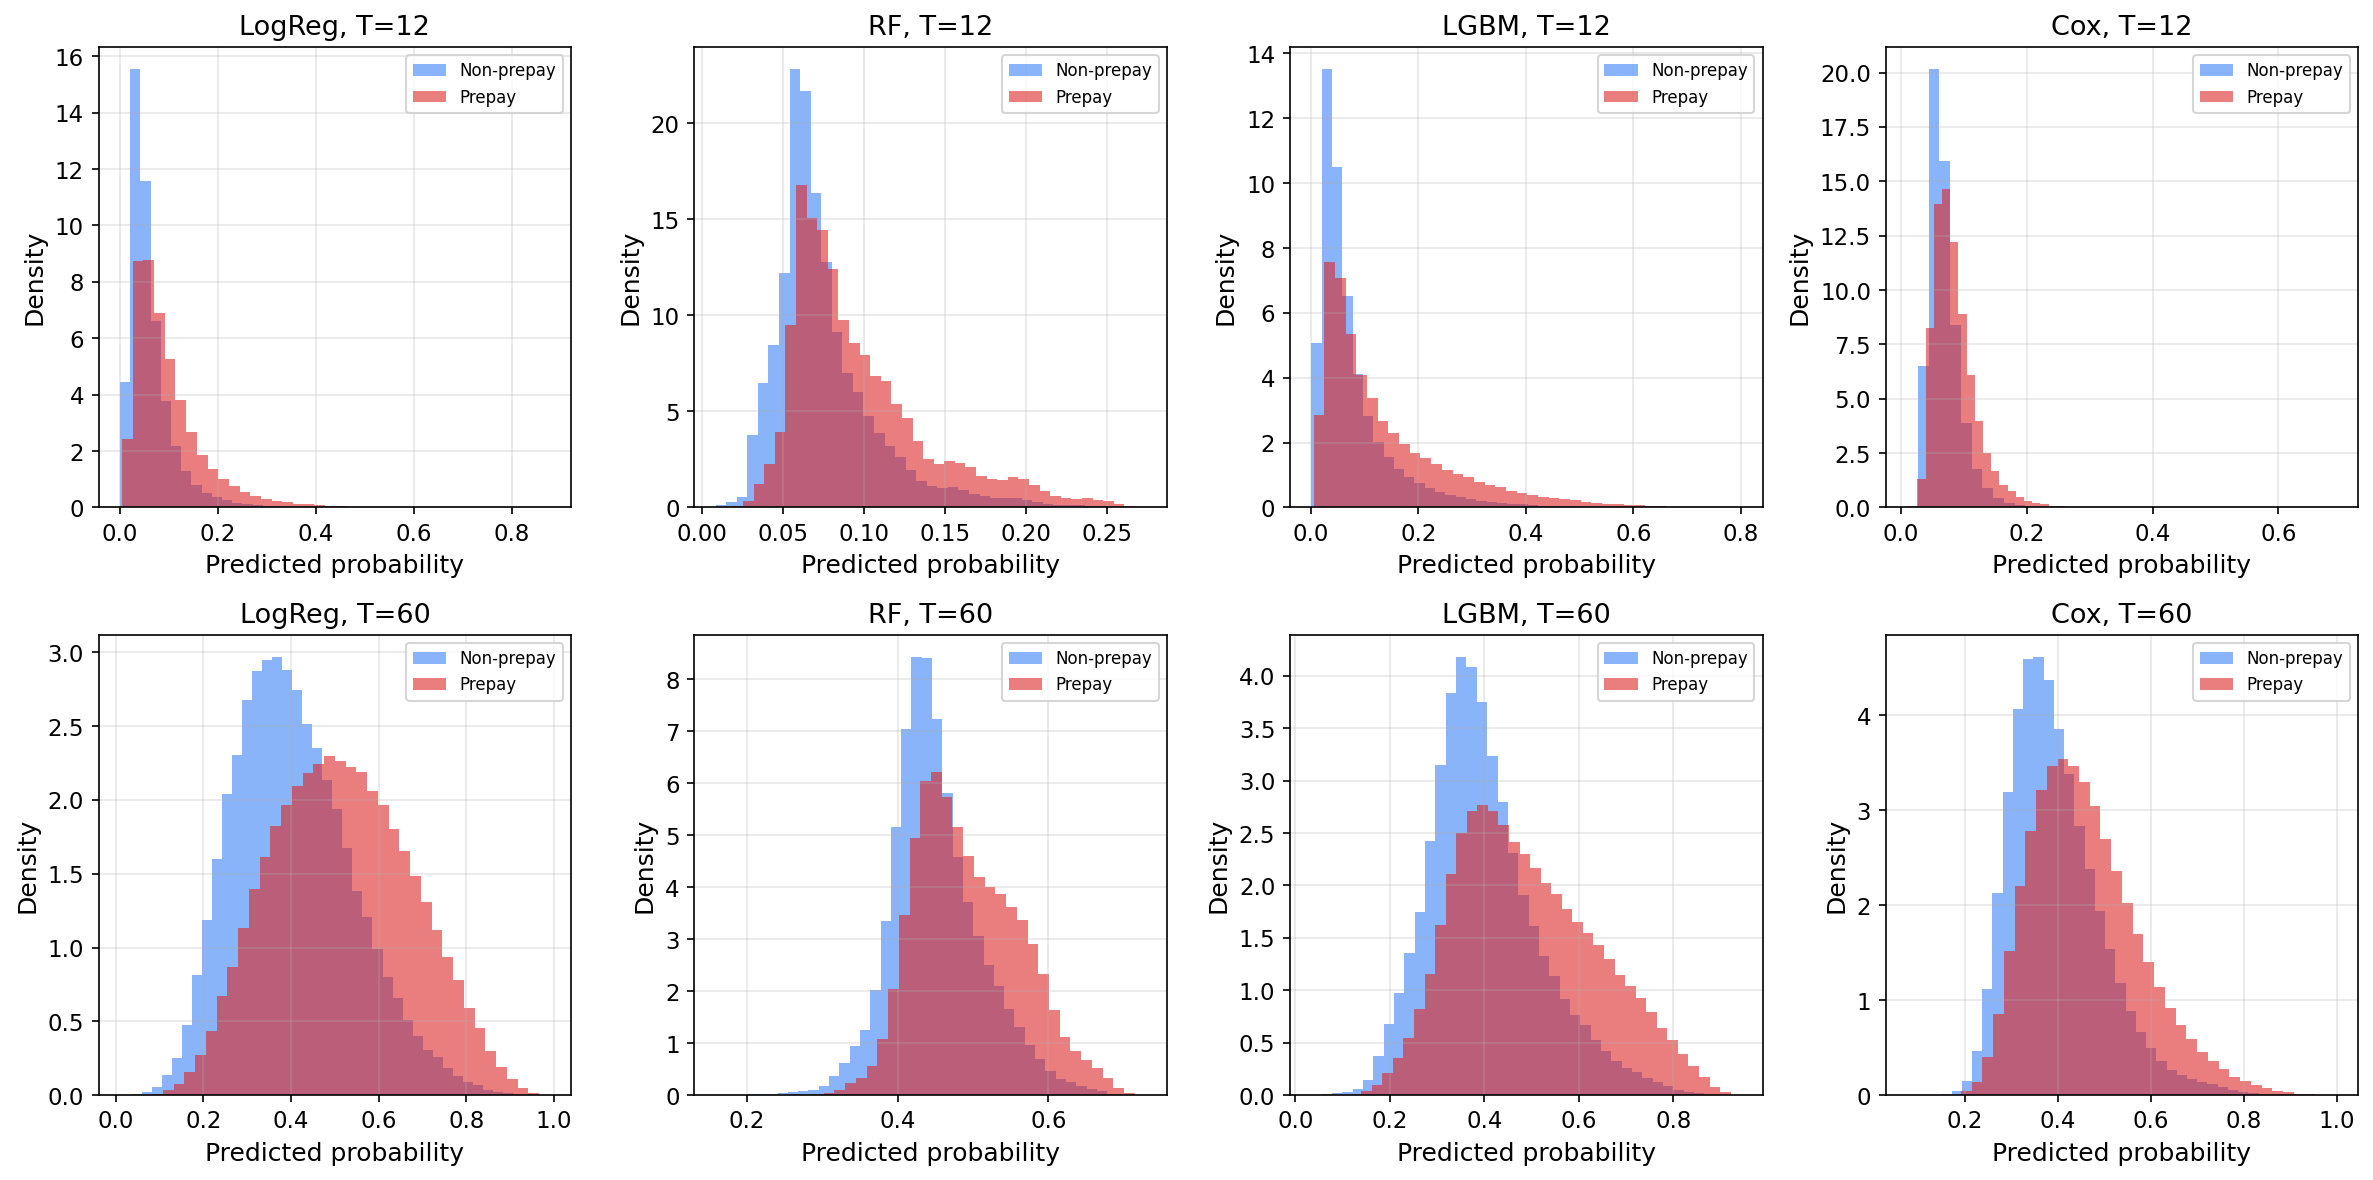

In [24]:
def plot_score_distributions(preds, models, horizons_to_show=None):
    if horizons_to_show is None:
        horizons_to_show = [12, 60]  # short and long
    fig, axes = plt.subplots(
        len(horizons_to_show), len(models),
        figsize=(4 * len(models), 4 * len(horizons_to_show)),
        squeeze=False,
    )
    for i, T in enumerate(horizons_to_show):
        target = preds[f"Target_T{T}"]
        valid_target = target.notna()
        for j, m in enumerate(models):
            ax = axes[i, j]
            pcol = f"pred_{m}_T{T}"
            if pcol not in preds.columns:
                continue
            valid = valid_target & preds[pcol].notna()
            if valid.sum() < 100:
                continue
            p = preds.loc[valid, pcol].values
            y = target[valid].astype(int).values
            ax.hist(p[y == 0], bins=40, alpha=0.6, color="#3B82F6",
                    label="Non-prepay", density=True)
            ax.hist(p[y == 1], bins=40, alpha=0.6, color="#DC2626",
                    label="Prepay", density=True)
            ax.set_xlabel("Predicted probability")
            ax.set_ylabel("Density")
            ax.set_title(f"{m}, T={T}")
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

plot_score_distributions(predictions, models_present)


## Feature importance

Top-15 features per model and horizon. Two caveats worth keeping in
mind:

- **LogReg** importance is the absolute value of the standardized
  coefficient � meaningful as a relative signed effect.
- **RF / LGBM** importance is impurity-based � relative within a model
  but not directly comparable across models, and biased toward
  high-cardinality features.


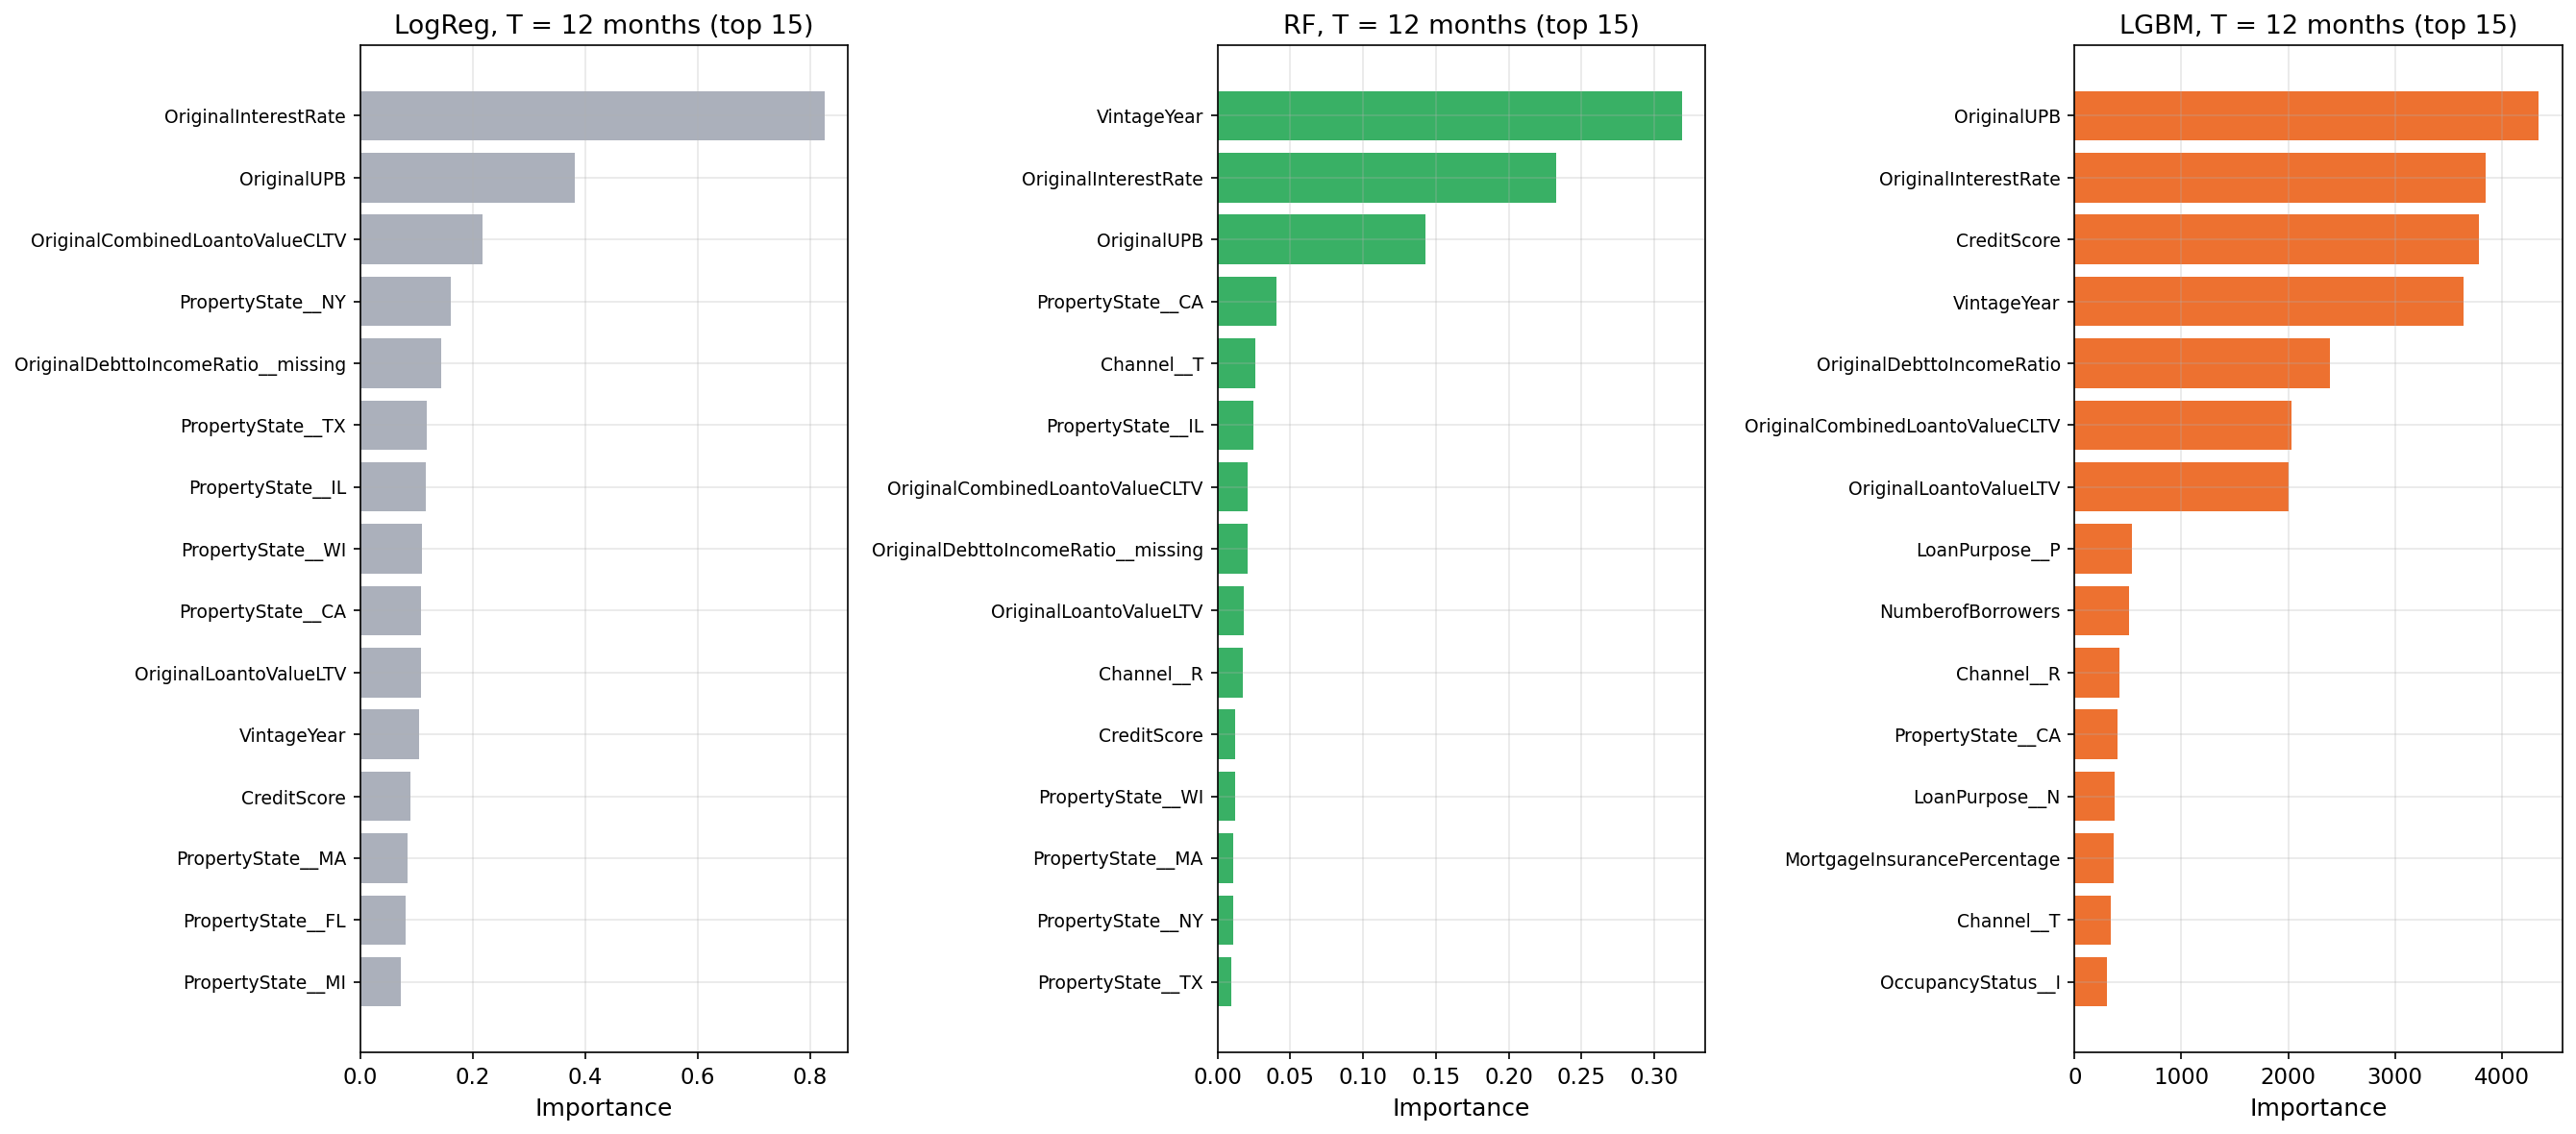

In [25]:
def plot_feature_importance(fi, models, horizon=12, top_k=15):
    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 8),
                              squeeze=False)
    axes = axes.ravel()
    for ax, m in zip(axes, models):
        sub = fi[(fi["model"] == m) & (fi["horizon"] == horizon)].copy()
        if sub.empty:
            ax.text(0.5, 0.5, f"No importance for {m} (T={horizon})",
                    ha="center", va="center", transform=ax.transAxes)
            continue
        sub = sub.sort_values("importance", ascending=False).head(top_k)
        sub = sub.iloc[::-1]  # so largest is at top
        labels = [LABEL_MAP.get(f, f) for f in sub["feature"]]
        ax.barh(range(len(sub)), sub["importance"].values,
                color=MODEL_COLORS[m], alpha=0.85)
        ax.set_yticks(range(len(sub)))
        ax.set_yticklabels(labels, fontsize=9)
        ax.set_xlabel("Importance")
        ax.set_title(f"{m}, T = {horizon} months (top {top_k})")
    fig.tight_layout()
    plt.show()

# Show feature importance for the shortest horizon (where signal is strongest)
ml_models = [m for m in models_present if m != "Cox"]
if ml_models:
    plot_feature_importance(feature_importance, ml_models, horizon=12)
else:
    print("No ML models with feature importance available.")


## Summary table

Compact metrics table for the report.


In [26]:
overall = metrics[metrics["stratum_type"] == "all"].copy()
summary = overall.pivot_table(
    index="model",
    columns="horizon",
    values=["auc", "brier", "log_loss"],
    aggfunc="first",
)
print(f"Target mode: {TARGET_MODE!r}")
print()
print("Overall test-set metrics, by model and horizon:")
print(summary.round(4).to_string())


Target mode: 'cause_specific'

Overall test-set metrics, by model and horizon:
            auc                           brier                         log_loss                        
horizon      12      24      36      60      12      24      36      60       12      24      36      60
model                                                                                                   
Cox      0.6635  0.6571  0.6596  0.6650  0.0949  0.2048  0.2527  0.2659   0.3359  0.6022  0.7027  0.7263
LGBM     0.6805  0.6738  0.6899  0.6825  0.0916  0.1941  0.2343  0.2503   0.3264  0.5823  0.6659  0.6940
LogReg   0.6908  0.6670  0.6837  0.7043  0.0932  0.2119  0.2500  0.2366   0.3315  0.6363  0.7029  0.6656
RF       0.6706  0.6519  0.6718  0.6803  0.0939  0.2050  0.2475  0.2456   0.3305  0.6010  0.6887  0.6842


## Caveats and reading guide

- **Cause-specific framing.** When `target_mode == "cause_specific"`,
  test loans that experienced a non-prepayment termination before
  horizon $T$ are excluded from the metrics calculation at that
  horizon. This is the same estimand Cox produces and keeps the
  comparison fair, but it does mean the test set shrinks at longer
  horizons.

- **Cox via $1 - \hat S(T \mid X)$.** Cox is a continuous-time
  hazard model; we evaluate it at four discrete horizons by reading
  off the survival function. If you wanted a true cause-specific
  Fine-Gray subdistribution-hazard model, that's the Part E
  extension.

- **Concern 12 sensitivity.** If `--drop-vintage-year` was passed when
  Part C was run, the feature `VintageYear` is absent from the X
  matrix. A separate run with the flag flipped lets you compare the
  AUC charts above and judge how much the model relies on
  calendar-year information.

- **Concern 1 / 5 contracts.** This notebook reads only the parquet
  outputs of `part_c_ml_models.py`. The feature-matrix fitting was
  done on training data only (concern 1) and the canonical split file
  is the source of truth for which loans are in train vs test
  (concern 5).
